Ciclo Crisis 52-55 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)


Datos cargados: 1980–2023
Columnas: ['gastos_consumo', 'consumo_privado', 'consumo_publico', 'variacion_existencias', 'formacion_capital', 'exportacion_bienes_servicios', 'importacion_bienes', 'pib_a_precios_corrientes']


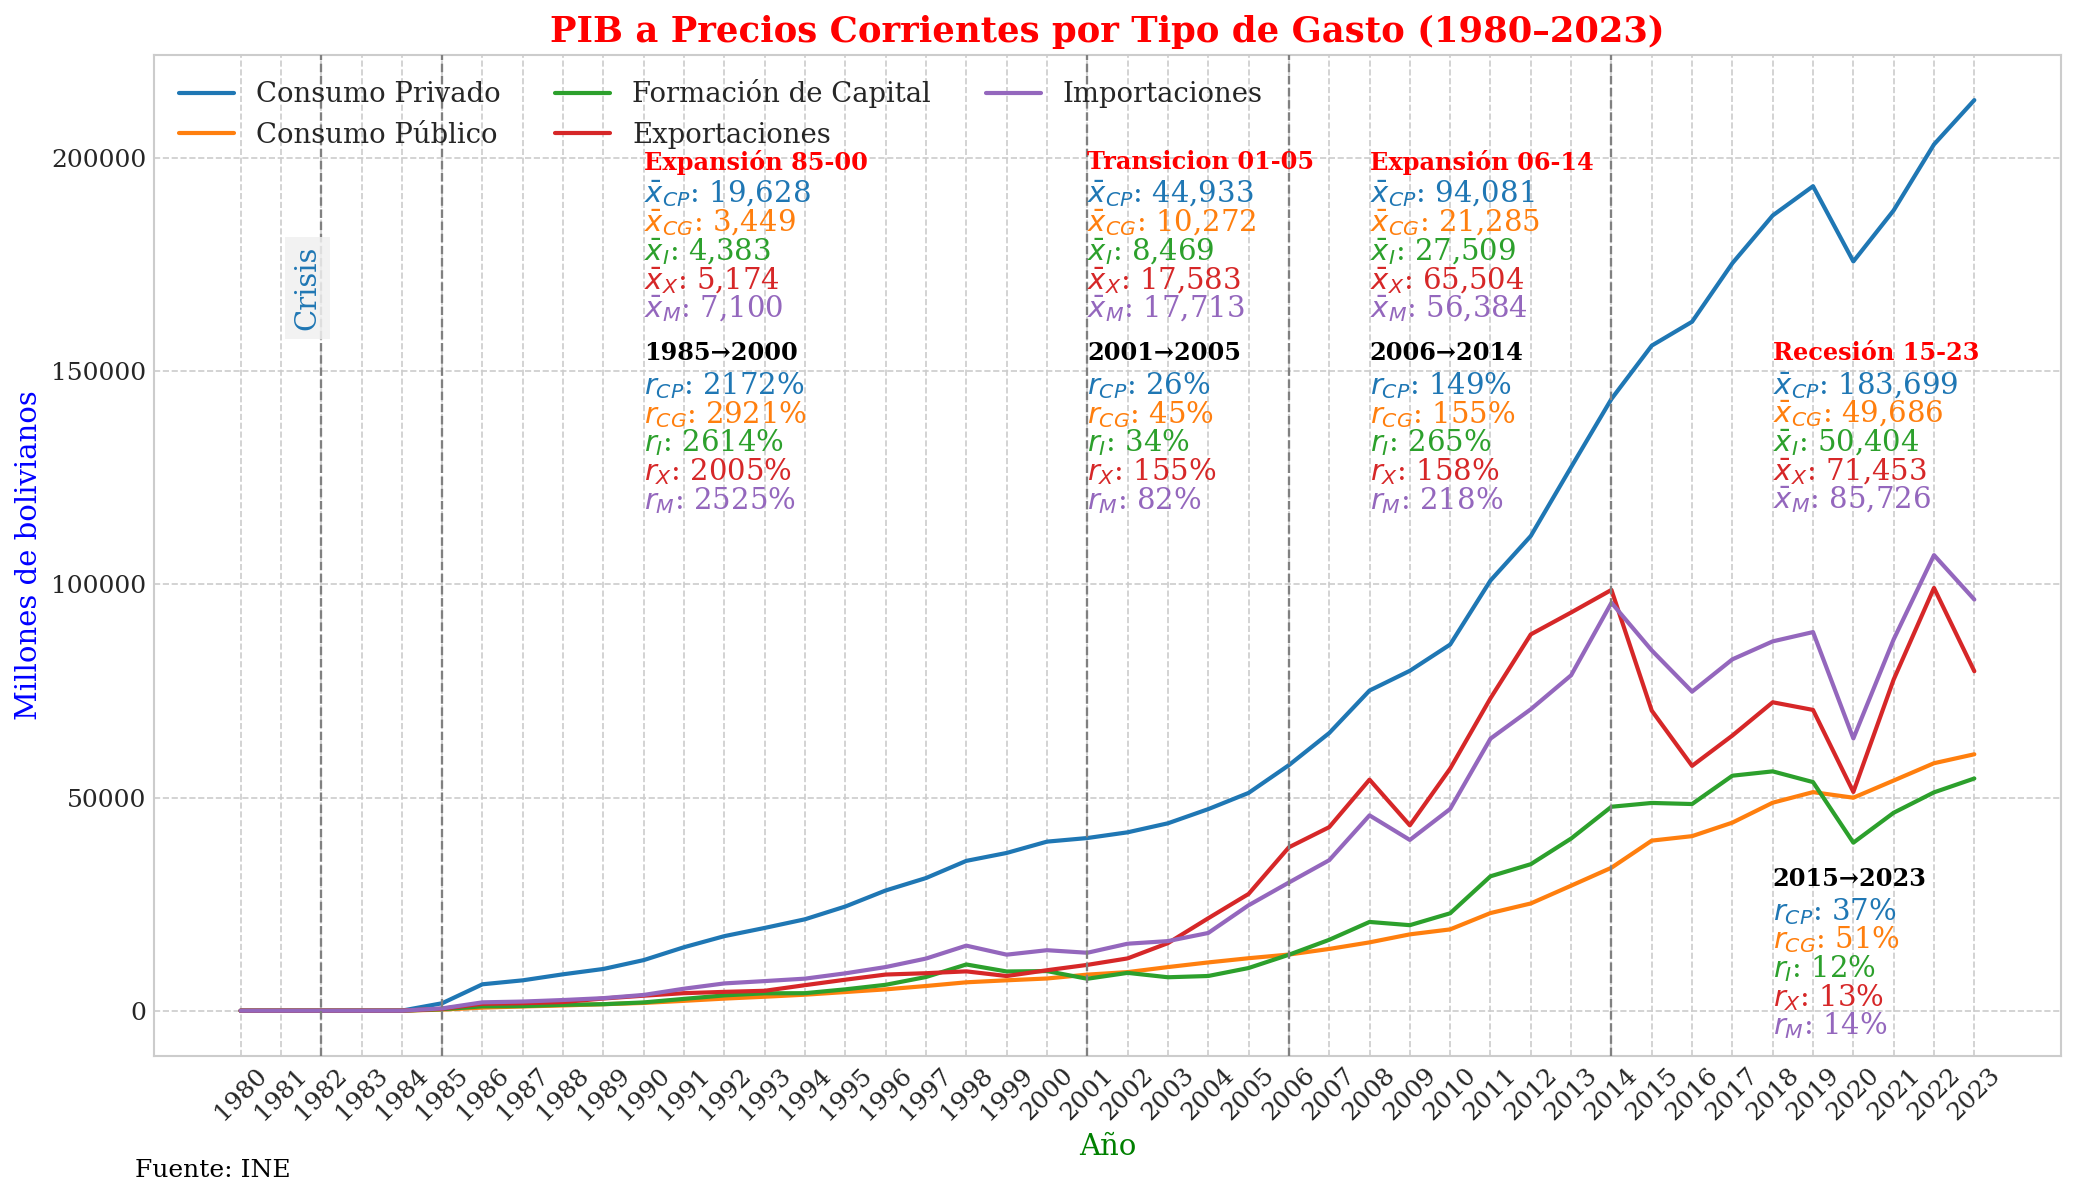

Gráfico guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/pib_nominal_gasto/pib_nominal_gasto_componentes.png


In [21]:
# ───────────────────────────── IMPORTS ──────────────────────────────
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt 

# IMPORTANTE: Importación correcta de las funciones auxiliares
from func_auxiliares.graficos_utils import (
    set_style,                          # Estilo corporativo
    init_base_plot,                     # Configuración base del gráfico
    add_hitos,                          # Líneas verticales de hitos
    add_cycle_means_multi,              # Medias por ciclo
    add_year_value_annotations,         # Anotaciones de valores por año
    add_period_growth_annotations_multi,# Tasas de crecimiento por período
    adjust_annot_years,                 # Ajustar años de anotación al DataFrame
    adjust_cycles,                      # Ajustar ciclos al DataFrame
    adjust_periods,                     # Ajustar períodos al DataFrame
)

from func_auxiliares.config import (
    DB_PATH,                            # Ruta a la base de datos
    CYCLES,                             # Diccionario de ciclos económicos
    annot_years,                        # Lista de años para anotaciones
    periodos_tasas,                     # Períodos para calcular tasas
    hitos_v,                            # Diccionario de hitos verticales
    ASSETS_DIR,
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
output_dir = ASSETS_DIR/ "serie_completa" / "pib_nominal_gasto"
os.makedirs(output_dir, exist_ok=True)

set_style()  # Aplica el estilo corporativo unificado
# ───────────────────────── 2. CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM pib_nominal_gasto",
            conn,
            index_col="año"
        )
        .sort_index()
    )

# Convertir miles a millones para mejor legibilidad
valor_cols = ['gastos_consumo', 'consumo_privado', 'consumo_publico', 
              'formacion_capital', 'exportacion_bienes_servicios', 
              'importacion_bienes', 'pib_a_precios_corrientes']
df[valor_cols] = df[valor_cols] / 1000  # Miles a millones

print(f"Datos cargados: {df.index.min()}–{df.index.max()}")
print(f"Columnas: {list(df.columns)}")
df.head()
# ──────────────── 3. COMPONENTES Y PREPARACIÓN ──────────────────────
# Definir las series a graficar (tuplas de columna_df, etiqueta_display)
componentes = [
    ("consumo_privado", "Consumo Privado"),
    ("consumo_publico", "Consumo Público"),
    ("formacion_capital", "Formación de Capital"),
    ("exportacion_bienes_servicios", "Exportaciones"),
    ("importacion_bienes", "Importaciones"),
]

# Extraer solo los nombres de columnas
cols_componentes = [col for col, _ in componentes]

# Definir colores para cada serie
colors = {
    "consumo_privado": "#1f77b4",               # Azul
    "consumo_publico": "#ff7f0e",               # Naranja
    "formacion_capital": "#2ca02c",             # Verde
    "exportacion_bienes_servicios": "#d62728",  # Rojo
    "importacion_bienes": "#9467bd",            # Púrpura
}

# Abreviaciones para anotaciones (texto más corto)
abbr_map = {
    "consumo_privado": "CP",
    "consumo_publico": "CG",
    "formacion_capital": "I",
    "exportacion_bienes_servicios": "X",
    "importacion_bienes": "M",
}
# ──────────────── 4. PREPARACIÓN DE CICLOS Y PERÍODOS ────────────────
# Ajustar configuraciones globales al DataFrame actual
annotate_years = adjust_annot_years(df, annot_years)
cycles = adjust_cycles(df, CYCLES)
periods = adjust_periods(df, periodos_tasas)

# Calcular estadísticas por ciclo (medias)
cycle_stats = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in cycles.items()
}
# ───────────── 5. OFFSETS Y UTILIDADES (POSICIONAMIENTO) ────────────

# A) Offsets para anotaciones de valores por año y serie
annotation_offsets = {
    # "consumo_privado": {
    #     1985: (0, 800),
    #     2001: (0, 1200),
    #     2006: (-1.5, 400),
    #     2014: (-3.2, -400),
    # },
    # "consumo_publico": {
    #     1985: (0, 300),
    #     2001: (0, 400),
    #     2006: (1.2, -200),
    #     2014: (4, 0),
    # },
    # "formacion_capital": {
    #     1985: (0, 200),
    #     2001: (0, 300),
    #     2006: (0, 500),
    #     2014: (0, 600),
    # },
    # "exportacion_bienes_servicios": {
    #     1985: (0, 150),
    #     2001: (0, 400),
    #     2006: (0, 800),
    #     2014: (0, 1000),
    # },
    # "importacion_bienes": {
    #     1985: (0, -200),
    #     2001: (0, -300),
    #     2006: (0, -400),
    #     2014: (0, -500),
    # },
}

# B) Offsets para líneas verticales de hitos
hitos_offset = {year: 0.8 for year in hitos_v}  # Altura relativa uniforme

# C) Offsets para medias por ciclo
medias_offsets = {
    "Expansión 85-00": (1990, 0.90),
    "Transicion 01-05": (2001, 0.90),
    "Expansión 06-14": (2008, 0.90),
    "Recesión 15-23": (2018, 0.7),
}

# D) Offsets para tasas de crecimiento por período
tasas_offsets = {
    "1985-2000": (1990, 0.7),
    "2001-2005": (2001, 0.7),
    "2006-2014": (2008, 0.7),
    "2015-2023": (2018, 0.15),
}

# ────────────────────────── 6. GRÁFICO BASE ──────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,           # Lista de tuplas (columna, etiqueta)
    colors=colors,                # Diccionario de colores
    title=f"PIB a Precios Corrientes por Tipo de Gasto ({df.index.min()}–{df.index.max()})",
    xlabel="Año",
    ylabel="Millones de bolivianos",
    source_text="Fuente: INE",
    figsize=(14, 8),             # Tamaño de figura
    legend_loc="upper left"       # Ubicación de leyenda
)
# ────────────────────── 7. ELEMENTOS GRÁFICOS ADICIONALES ────────────

# A) Líneas verticales de hitos históricos
add_hitos(ax, df.index, hitos_v, hitos_offset)

# B) Anotaciones de valores en años específicos
add_year_value_annotations(
    ax, df, annotate_years,
    cols_componentes, annotation_offsets, colors,
    arrow_lw=0.4,                # Grosor de flecha
)
y_max = ax.get_ylim()[1]
line_spacing = y_max * 0.03
# C) Medias por ciclo económico
add_cycle_means_multi(
    ax,
    cycle_stats,
    medias_offsets,
    abbr_map,
    colors,
    line_spacing=line_spacing
)

# D) Tasas de crecimiento por período
add_period_growth_annotations_multi(
    ax, df, periods,
    cols_componentes,
    tasas_offsets,
    colors,
    abbr_map
)
# ────────────────────────── 8. FINALIZACIÓN ──────────────────────────
plt.tight_layout()

# Guardar en formato PNG
filename_base = f"{output_dir}/pib_nominal_gasto_componentes"
fig.savefig(f"{filename_base}.png", dpi=300, bbox_inches="tight")

plt.show()

print(f"Gráfico guardado en: {filename_base}.png")